In [93]:
import pandas as pd
import matplotlib as plt
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics


In [96]:
# Obtener el dataset de mediciones de monóxido de carbono
#url = "https://rconnect-public.epa.gov/AirData/_w_405494c98f684bfb888f3297a4d2c48f/session/4b6a93391d45bf194ae3ca62714740bc/download/daily_download?w=405494c98f684bfb888f3297a4d2c48f"
df = pd.read_csv("/content/CO_daily_aqs_data_downloaded_2026-09-17 21_56_43.csv")
df.head()

,Date,Site ID,POC,Daily Max CO Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,AQS Parameter Code,...,Elevation (m),Measurement Scale,Measurement Scale Definition,Monitor Type,Monitoring Agency,Monitoring Objective,NAAQS Primary Monitor?,Networks,Probe Height (m),QA Primary Monitor?
0,2022-01-01,10730023,2,0.1,Parts per million,1,North Birmingham,19,79,42101,...,177.0,NEIGHBORHOOD,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",OTHER,NaN,NCORE,17.5,NaN
1,2022-01-02,10730023,2,0.2,Parts per million,2,North Birmingham,24,100,42101,...,177.0,NEIGHBORHOOD,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",OTHER,NaN,NCORE,17.5,NaN
2,2022-01-03,10730023,2,0.2,Parts per million,2,North Birmingham,12,50,42101,...,177.0,NEIGHBORHOOD,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",OTHER,NaN,NCORE,17.5,NaN
3,2022-01-04,10730023,2,0.2,Parts per million,2,North Birmingham,4,17,42101,...,177.0,NEIGHBORHOOD,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",OTHER,NaN,NCORE,17.5,NaN
4,2022-01-05,10730023,2,0.5,Parts per million,6,North Birmingham,9,38,42101,...,177.0,NEIGHBORHOOD,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",OTHER,NaN,NCORE,17.5,NaN


In [97]:
# Convertir mesese en funciones de senos y cosenos
df["Date"] = pd.to_datetime(df["Date"])

fecha_inicio = pd.Timestamp("2022-01-01")

df["Date_sin"] = np.sin(2 * np.pi * (df["Date"] - fecha_inicio).dt.days / 365.25)
df["Date_cps"] = np.cos(2 * np.pi * (df["Date"] - fecha_inicio).dt.days / 365.25)

df.head()

,Date,Site ID,POC,Daily Max CO Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,AQS Parameter Code,...,Measurement Scale Definition,Monitor Type,Monitoring Agency,Monitoring Objective,NAAQS Primary Monitor?,Networks,Probe Height (m),QA Primary Monitor?,Date_sin,Date_cps
0,2022-01-01,10730023,2,0.1,Parts per million,1,North Birmingham,19,79,42101,...,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",OTHER,NaN,NCORE,17.5,NaN,0.000000,1.000000
1,2022-01-02,10730023,2,0.2,Parts per million,2,North Birmingham,24,100,42101,...,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",OTHER,NaN,NCORE,17.5,NaN,0.017202,0.999852
2,2022-01-03,10730023,2,0.2,Parts per million,2,North Birmingham,12,50,42101,...,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",OTHER,NaN,NCORE,17.5,NaN,0.034398,0.999408
3,2022-01-04,10730023,2,0.2,Parts per million,2,North Birmingham,4,17,42101,...,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",OTHER,NaN,NCORE,17.5,NaN,0.051584,0.998669
4,2022-01-05,10730023,2,0.5,Parts per million,6,North Birmingham,9,38,42101,...,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",OTHER,NaN,NCORE,17.5,NaN,0.068755,0.997634


In [98]:
# Eliminar variables no relevantes
to_drop = ["Date", "Site ID", "Units", "Local Site Name", "AQS Parameter Code", "Monitor Type",
           "Monitoring Agency", "Monitoring Objective", "NAAQS Primary Monitor?", "Networks",
           "QA Primary Monitor?", "AQS Parameter Description", "Method Description", "CBSA Name",
           "Measurement Scale Definition", "Measurement Scale", "Dominant Source", "CBSA Code",
           "Method Code"]
df2 = df.drop(to_drop, axis=1)
df2.head()

,POC,Daily Max CO Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,Site Latitude,Site Longitude,Elevation (m),Probe Height (m),Date_sin,Date_cps
0,2,0.1,1,19,79,33.553056,-86.815,177.0,17.5,0.000000,1.000000
1,2,0.2,2,24,100,33.553056,-86.815,177.0,17.5,0.017202,0.999852
2,2,0.2,2,12,50,33.553056,-86.815,177.0,17.5,0.034398,0.999408
3,2,0.2,2,4,17,33.553056,-86.815,177.0,17.5,0.051584,0.998669
4,2,0.5,6,9,38,33.553056,-86.815,177.0,17.5,0.068755,0.997634


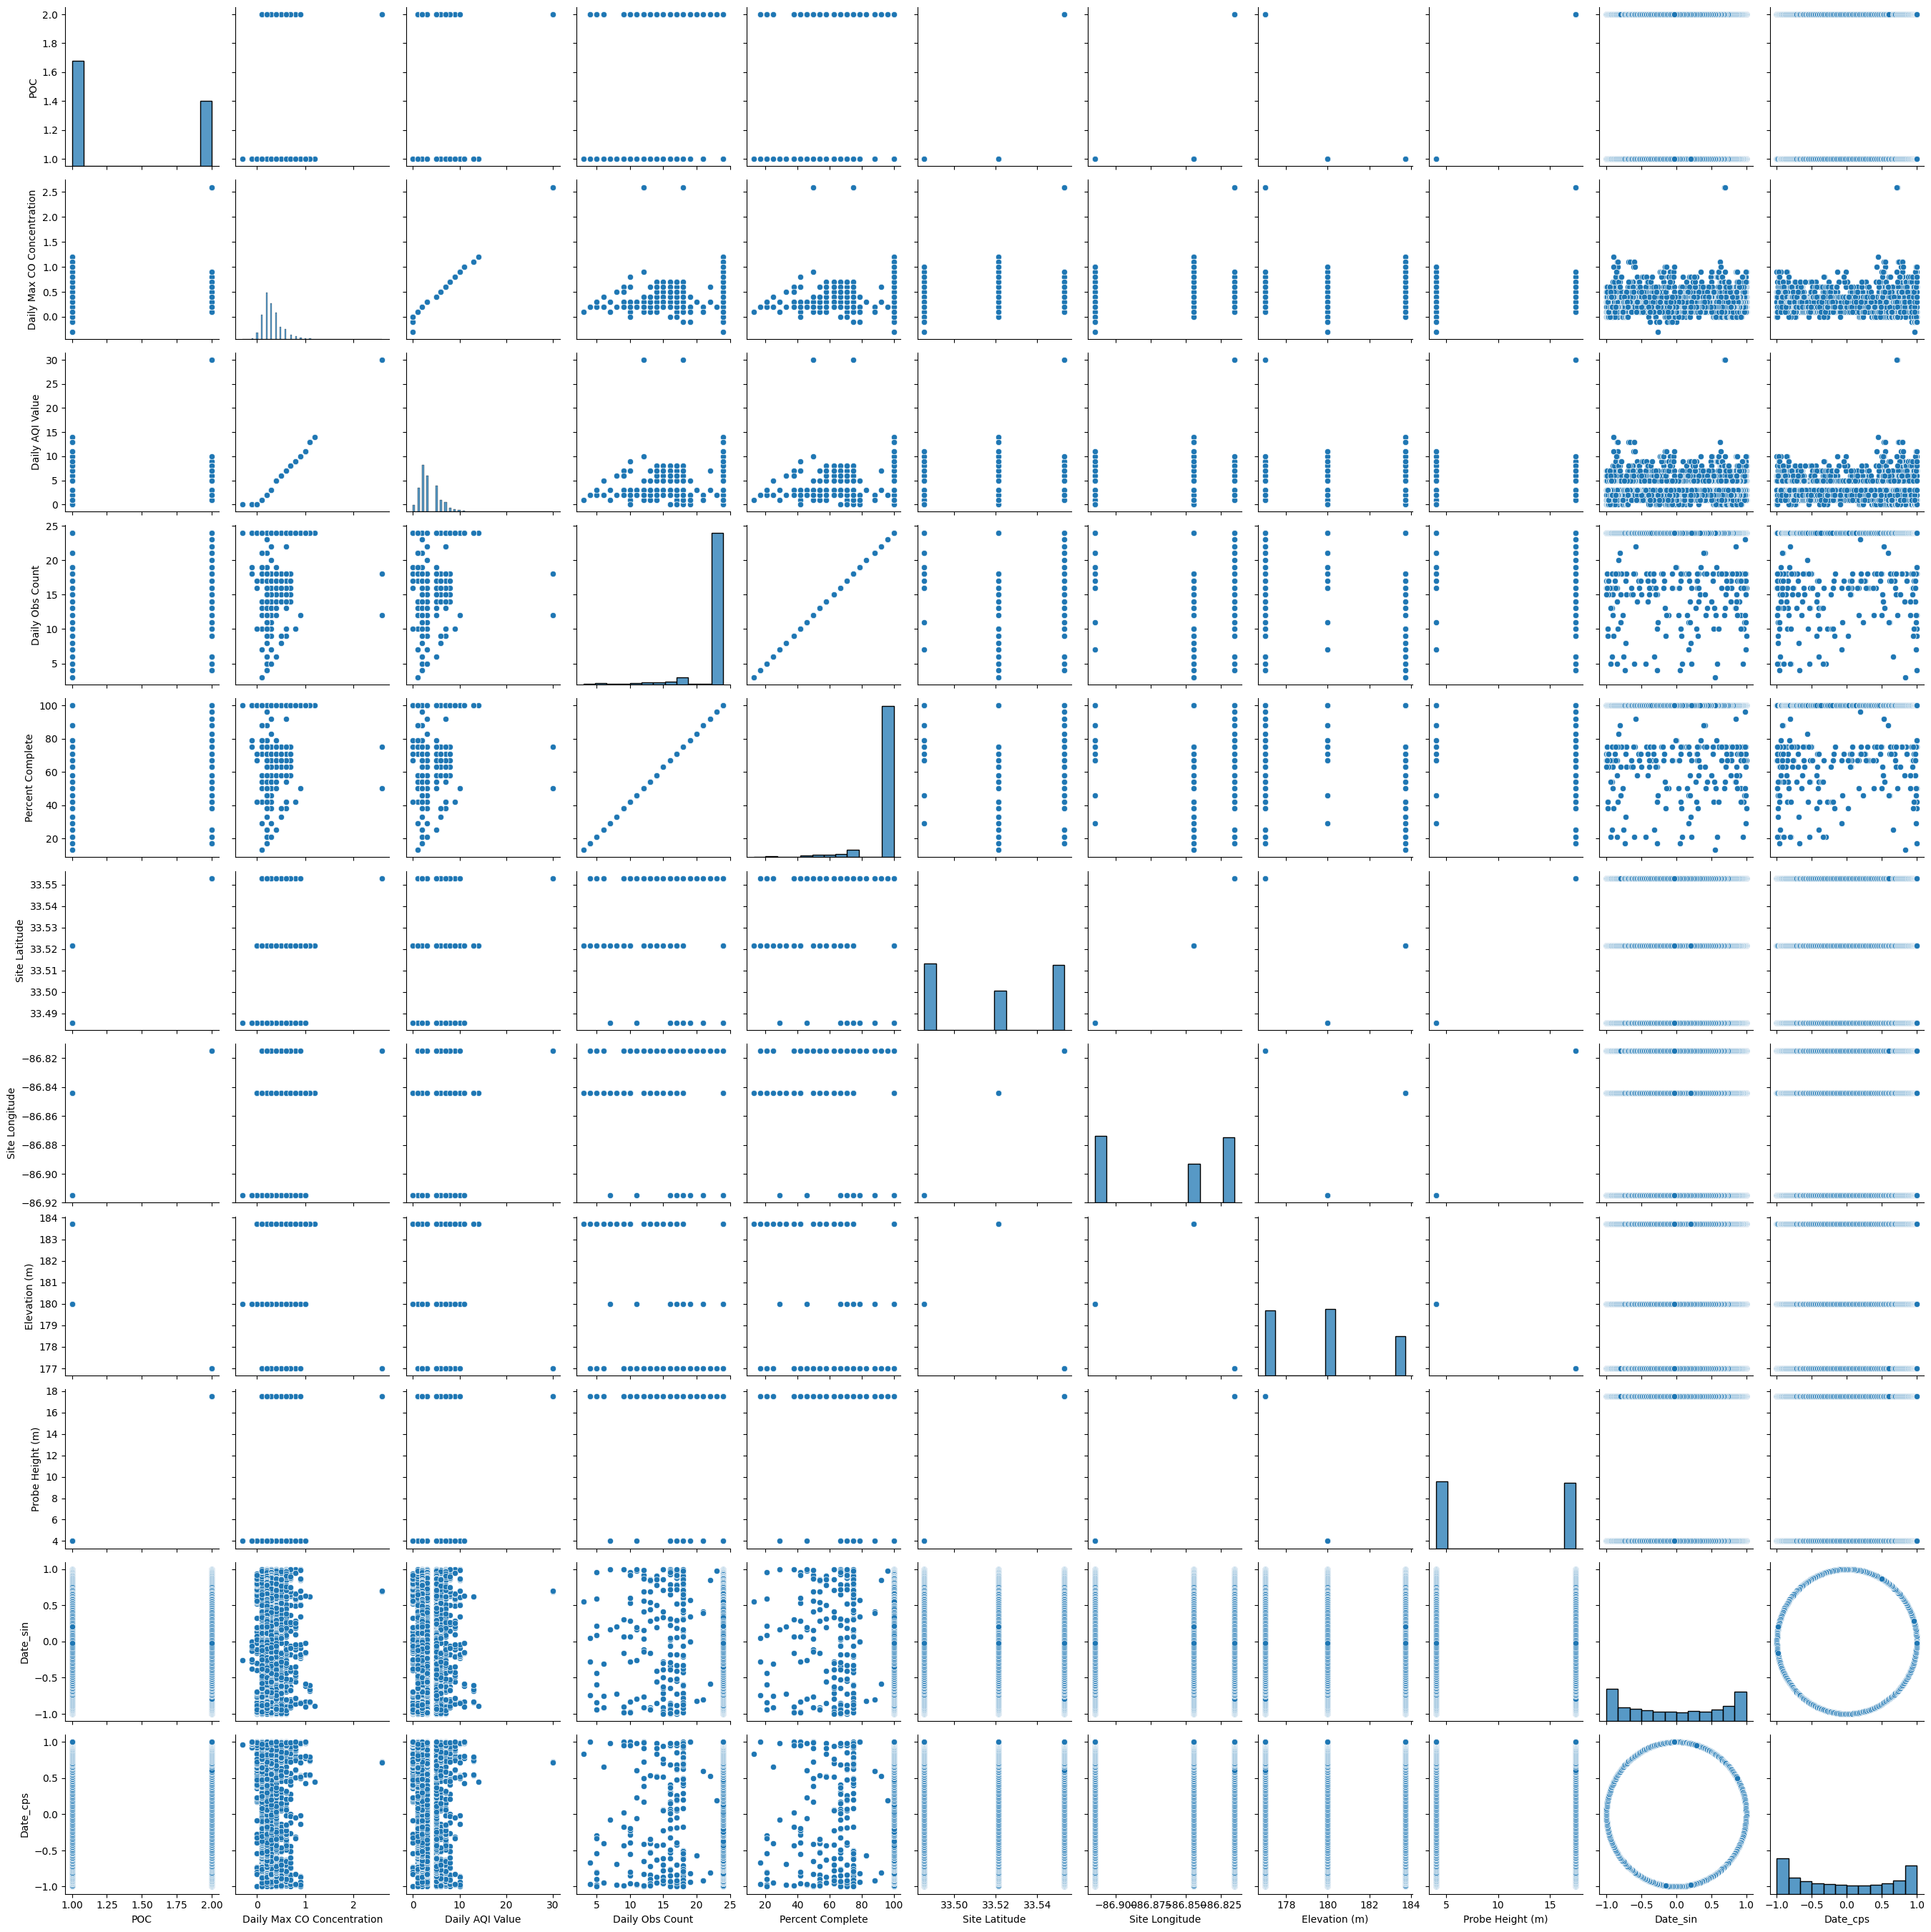

In [99]:
# Para una intuición de qué relaciones hay entre las variables
sns.pairplot(df2)

<Axes: >

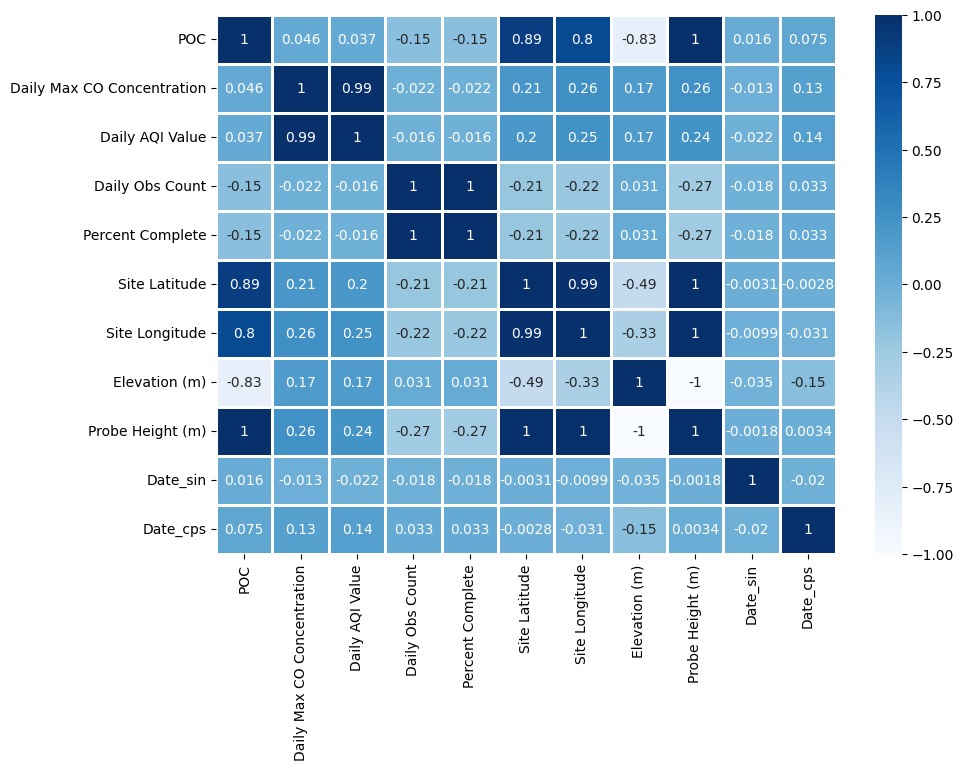

In [100]:
# Mapa de correlaciones, no se ve uno muy fuerte para Daily Max CO Concentration, aparte de AQi
plt.figure(figsize=(10,7))
sns.heatmap(df2.corr(), annot=True, cmap="Blues", linewidths = 2)

In [101]:
# Dividir train y test 70/30 y utilizar el modelo de regresión lineal
df2 = df2.fillna(0)
x = df2.drop(["Daily Max CO Concentration"], axis = 1)
y = df2["Daily Max CO Concentration"]
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.3, random_state = 123)

ln = LinearRegression()
ln.fit(x_train, y_train)

LinearRegression()

In [102]:
y_pred = ln.predict(x_test)

In [103]:
# Observar RMSE
rmse = np.sqrt(metrics.root_mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 0.15765386132628142


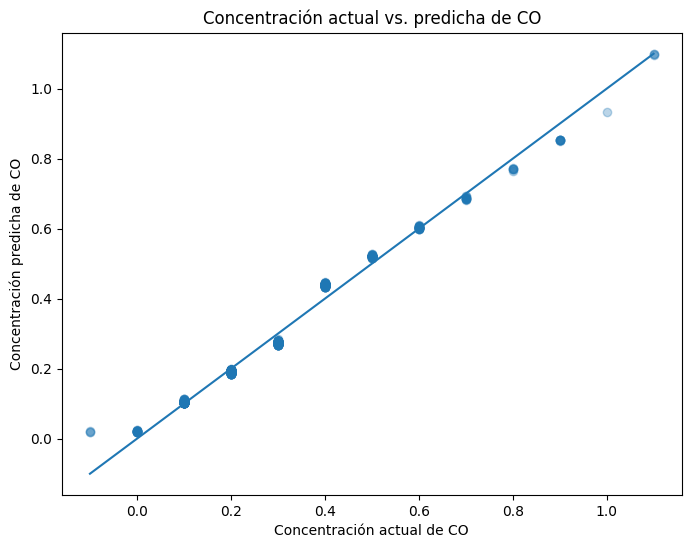

In [105]:
# Comparar actual vs predicho

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Concentración actual de CO")
plt.ylabel("Concentración predicha de CO")
plt.title("Concentración actual vs. predicha de CO")

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

plt.plot(lims, lims)

plt.show()

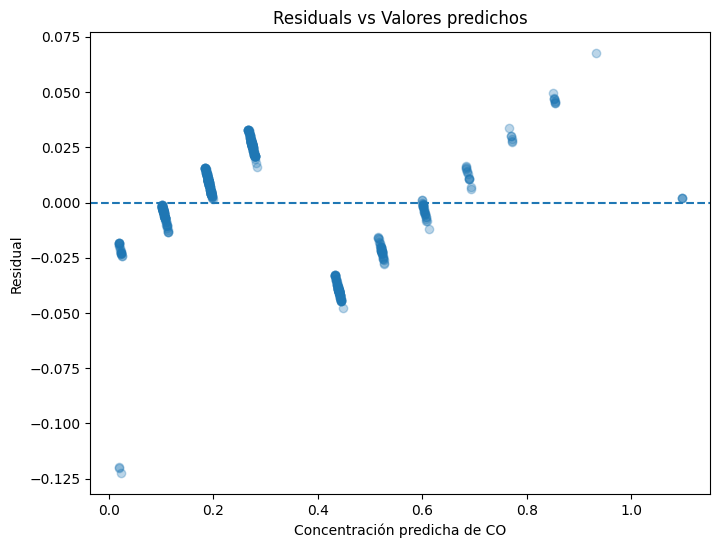

In [106]:
# Observar residuales

residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.3)

plt.axhline(0, linestyle="--")

plt.xlabel("Concentración predicha de CO")
plt.ylabel("Residual")
plt.title("Residuals vs Valores predichos")

plt.show()

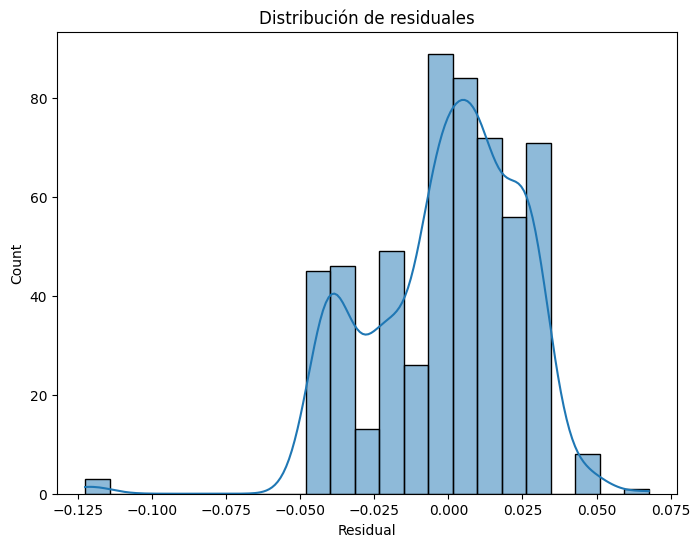

In [107]:
# Observar la distribución de residuales

plt.figure(figsize=(8, 6))

sns.histplot(residuals, kde=True)

plt.xlabel("Residual")
plt.title("Distribución de residuales")

plt.show()

In [114]:
# Repetir, sin "Daily AQI Value"
df2 = df2.fillna(0)
x = df2.drop(["Daily Max CO Concentration", "Daily AQI Value"], axis = 1)
y = df2["Daily Max CO Concentration"]
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.3, random_state = 123)

ln = LinearRegression()
ln.fit(x_train, y_train)

LinearRegression()

In [115]:
y_pred = ln.predict(x_test)
# Observar RMSE
rmse = np.sqrt(metrics.root_mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 0.4121573825865062


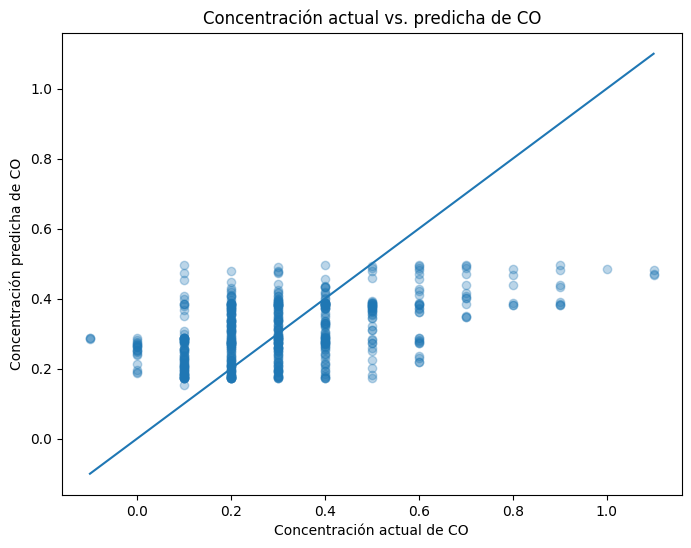

In [116]:
# Comparar actual vs predicho

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Concentración actual de CO")
plt.ylabel("Concentración predicha de CO")
plt.title("Concentración actual vs. predicha de CO")

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

plt.plot(lims, lims)

plt.show()

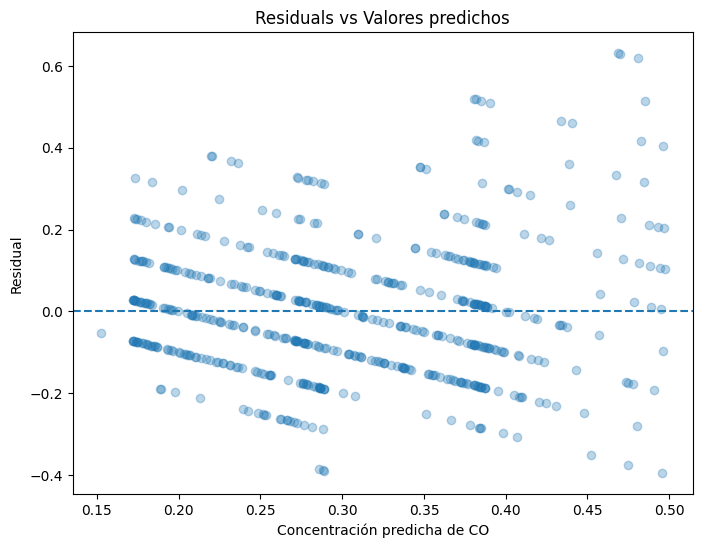

In [117]:
# Observar residuales

residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.3)

plt.axhline(0, linestyle="--")

plt.xlabel("Concentración predicha de CO")
plt.ylabel("Residual")
plt.title("Residuals vs Valores predichos")

plt.show()

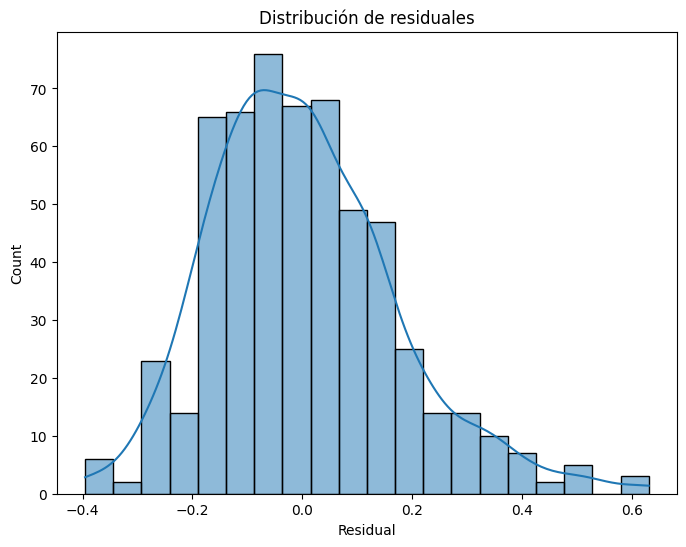

In [118]:
# Observar la distribución de residuales

plt.figure(figsize=(8, 6))

sns.histplot(residuals, kde=True)

plt.xlabel("Residual")
plt.title("Distribución de residuales")

plt.show()